In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
file_path = "combined.csv"   
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   52    1                1         125.0        212.0                    0   
1   53    1                1         140.0        203.0                    1   
2   70    1                1         145.0        174.0                    0   
3   61    1                1         148.0        203.0                    0   
4   62    0                1         138.0        294.0                    1   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            1             168                0      1.0         2       0  
1            0             155                1      3.1         0       0  
2            1             125                1      2.6         0       0  
3            1             161                0      0.0         2       0  
4            1             106                0      1.9         1       0  

Shape of dataset:
(1220, 12)


In [3]:
df["ST slope"] = df["ST slope"].replace(0, np.nan)

In [4]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
target                   0
dtype: int64

In [5]:
bp_index = df[df['resting bp s'].isna()].index

df.drop(bp_index, inplace=True)

In [6]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             0
cholesterol            171
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
target                   0
dtype: int64

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
numerical_nan = ["cholesterol"]
numerical_clean = ["age", "resting bp s", "max heart rate", "oldpeak"]

categorical_nan = ["ST slope"]
categorical_clean = ["chest pain type", "resting ecg"]

binary_features = ["sex", "fasting blood sugar", "exercise angina"]



In [9]:
numerical_nan_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_nan_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_clean_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocess = ColumnTransformer([
    ("num_nan", numerical_nan_transformer, numerical_nan),
    ("num_clean", "passthrough", numerical_clean),
    ("cat_nan", categorical_nan_transformer, categorical_nan),
    ("cat_clean", categorical_clean_transformer, categorical_clean),
    ("bin", "passthrough", binary_features)
])

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
param_grid = {
    "rf__n_estimators": [100, 200, 300, 400],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__class_weight": [None, "balanced"]
}

In [13]:
pipeline = Pipeline([ 
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(random_state=42)) 
])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


In [14]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__class_weight': [None, 'balanced'], 'rf__max_depth': [None, 5, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num_nan', ...), ('num_clean', ...), ...]"


In [15]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'rf__class_weight': None, 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 400}

Best Cross-Validation Score:
0.8287179487179488


In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [17]:
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy:
0.7786885245901639

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       106
           1       0.81      0.79      0.80       138

    accuracy                           0.78       244
   macro avg       0.77      0.78      0.78       244
weighted avg       0.78      0.78      0.78       244


Confusion Matrix:
[[ 81  25]
 [ 29 109]]


In [18]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
rf_model = best_model.named_steps["rf"]
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance": importances
})

imp_df["feature_raw"] = (
    imp_df["feature_transformed"]
    .str.split("__").str[-1]       # حذف prefix
    .str.split("_").str[0]         # حذف one-hot suffix
)

raw_importance = (
    imp_df.groupby("feature_raw")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(raw_importance)

            feature_raw  importance
0              ST slope    0.256412
1       chest pain type    0.144323
2           cholesterol    0.105384
3        max heart rate    0.100703
4                   age    0.088399
5               oldpeak    0.085837
6          resting bp s    0.085528
7           resting ecg    0.052245
8       exercise angina    0.035970
9                   sex    0.024702
10  fasting blood sugar    0.020498


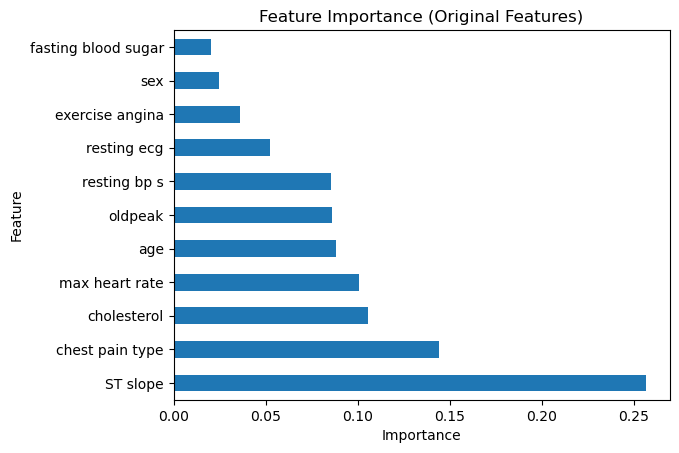

In [19]:
import matplotlib.pyplot as plt

raw_importance.plot(
    x="feature_raw",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Feature Importance (Original Features)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()